
# PyTorch Learning Notebook

This notebook is a practical guide to **PyTorch** and the most commonly used parts of the library.

It covers:
- Jupyter setup
- tensors, dtypes, shapes, and devices
- tensor creation and tensor math
- indexing, slicing, reshaping, and broadcasting
- autograd and gradients
- datasets and dataloaders
- building models with `torch.nn`
- losses, optimizers, and training loops
- evaluation and inference
- saving and loading models
- `torch.no_grad()` and `model.eval()`
- a small CNN example
- `torch.compile`
- common modules and inspection helpers

**Note:** PyTorch is a large library, so this notebook focuses on the **most used methods, functions, and features** rather than literally every API.



## 1) Jupyter setup

Install the basics:

```bash
pip install torch torchvision torchaudio numpy matplotlib pandas scikit-learn jupyter
jupyter notebook
```

If you use conda, install Jupyter and common packages there, then install PyTorch using the official selector from the PyTorch website for your OS, Python version, and CUDA/CPU setup.


In [1]:

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)


PyTorch version: 2.6.0
CUDA available: False
MPS available: True
Using device: mps


## 2) What is a tensor?

In [2]:

scalar = torch.tensor(5)
vector = torch.tensor([1, 2, 3])
matrix = torch.tensor([[1, 2], [3, 4]])
tensor3d = torch.tensor([[[1], [2]], [[3], [4]]])

print("scalar:", scalar)
print("vector:", vector)
print("matrix:\n", matrix)
print("tensor3d:\n", tensor3d)


scalar: tensor(5)
vector: tensor([1, 2, 3])
matrix:
 tensor([[1, 2],
        [3, 4]])
tensor3d:
 tensor([[[1],
         [2]],

        [[3],
         [4]]])


## 3) Tensor properties

In [3]:

x = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])

print("Tensor:\n", x)
print("shape:", x.shape)
print("ndim:", x.ndim)
print("dtype:", x.dtype)
print("device:", x.device)
print("numel:", x.numel())
print("size():", x.size())


Tensor:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
ndim: 2
dtype: torch.float32
device: cpu
numel: 6
size(): torch.Size([2, 3])


## 4) Creating tensors

In [4]:

zeros = torch.zeros((2, 3))
ones = torch.ones((2, 3))
full = torch.full((2, 3), 7)
eye = torch.eye(3)
arange_tensor = torch.arange(0, 10, 2)
linspace_tensor = torch.linspace(0, 1, 5)
rand_tensor = torch.rand((2, 3))
randn_tensor = torch.randn((2, 3))
randint_tensor = torch.randint(0, 10, (2, 3))

print("zeros:\n", zeros)
print("\nones:\n", ones)
print("\nfull:\n", full)
print("\neye:\n", eye)
print("\narange:", arange_tensor)
print("linspace:", linspace_tensor)
print("\nrand:\n", rand_tensor)
print("\nrandn:\n", randn_tensor)
print("\nrandint:\n", randint_tensor)


zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

full:
 tensor([[7, 7, 7],
        [7, 7, 7]])

eye:
 tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

arange: tensor([0, 2, 4, 6, 8])
linspace: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

rand:
 tensor([[0.8286, 0.2155, 0.4602],
        [0.6400, 0.9294, 0.9432]])

randn:
 tensor([[ 1.1728, -0.3542,  1.3973],
        [ 0.6302, -1.5591,  0.2402]])

randint:
 tensor([[3, 5, 9],
        [1, 4, 9]])


## 5) Dtypes and casting

In [5]:

x = torch.tensor([1, 2, 3], dtype=torch.int32)
y = x.float()
z = x.to(torch.float64)

print("Original:", x, x.dtype)
print("float():", y, y.dtype)
print("to(torch.float64):", z, z.dtype)


Original: tensor([1, 2, 3], dtype=torch.int32) torch.int32
float(): tensor([1., 2., 3.]) torch.float32
to(torch.float64): tensor([1., 2., 3.], dtype=torch.float64) torch.float64


## 6) NumPy conversion

In [6]:

x = torch.tensor([1.0, 2.0, 3.0])
x_np = x.numpy()

print("Torch tensor:", x)
print("NumPy array:", x_np)

back_to_torch = torch.from_numpy(x_np)
print("Back to torch:", back_to_torch)


Torch tensor: tensor([1., 2., 3.])
NumPy array: [1. 2. 3.]
Back to torch: tensor([1., 2., 3.])


## 7) Tensor indexing and slicing

In [7]:

x = torch.arange(1, 13).reshape(3, 4)

print("x:\n", x)
print("\nFirst row:", x[0])
print("Element at row 2, col 3:", x[1, 2])
print("Last column:", x[:, -1])
print("First two rows:\n", x[:2])
print("Submatrix:\n", x[1:, 1:3])


x:
 tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

First row: tensor([1, 2, 3, 4])
Element at row 2, col 3: tensor(7)
Last column: tensor([ 4,  8, 12])
First two rows:
 tensor([[1, 2, 3, 4],
        [5, 6, 7, 8]])
Submatrix:
 tensor([[ 6,  7],
        [10, 11]])


## 8) Reshaping, transpose, squeeze, unsqueeze

In [8]:

x = torch.arange(12)

reshaped = x.reshape(3, 4)
viewed = x.view(3, 4)
transposed = reshaped.T
flattened = reshaped.flatten()
unsqueezed = x.unsqueeze(0)
squeezed = torch.tensor([[[1], [2], [3]]]).squeeze()

print("Original:", x)
print("\nreshape:\n", reshaped)
print("\nview:\n", viewed)
print("\ntranspose:\n", transposed)
print("\nflatten:", flattened)
print("\nunsqueeze shape:", unsqueezed.shape)
print("squeeze:", squeezed)


Original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

reshape:
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

view:
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

transpose:
 tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])

flatten: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

unsqueeze shape: torch.Size([1, 12])
squeeze: tensor([1, 2, 3])


## 9) Concatenation and stacking

In [9]:

a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])

print("cat dim=0:\n", torch.cat([a, b], dim=0))
print("\ncat dim=1:\n", torch.cat([a, b], dim=1))
print("\nstack dim=0:\n", torch.stack([a, b], dim=0))
print("\nstack dim=1:\n", torch.stack([a, b], dim=1))


cat dim=0:
 tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])

cat dim=1:
 tensor([[1, 2, 5, 6],
        [3, 4, 7, 8]])

stack dim=0:
 tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])

stack dim=1:
 tensor([[[1, 2],
         [5, 6]],

        [[3, 4],
         [7, 8]]])


## 10) Basic math operations

In [10]:

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([10.0, 20.0, 30.0])

print("a + b =", a + b)
print("a - b =", a - b)
print("a * b =", a * b)
print("b / a =", b / a)
print("torch.add:", torch.add(a, b))
print("torch.square:", torch.square(a))
print("torch.sqrt:", torch.sqrt(b))
print("torch.exp:", torch.exp(a))
print("torch.log:", torch.log(a))
print("torch.sin:", torch.sin(a))
print("torch.cos:", torch.cos(a))


a + b = tensor([11., 22., 33.])
a - b = tensor([ -9., -18., -27.])
a * b = tensor([10., 40., 90.])
b / a = tensor([10., 10., 10.])
torch.add: tensor([11., 22., 33.])
torch.square: tensor([1., 4., 9.])
torch.sqrt: tensor([3.1623, 4.4721, 5.4772])
torch.exp: tensor([ 2.7183,  7.3891, 20.0855])
torch.log: tensor([0.0000, 0.6931, 1.0986])
torch.sin: tensor([0.8415, 0.9093, 0.1411])
torch.cos: tensor([ 0.5403, -0.4161, -0.9900])


## 11) Reductions and statistics

In [11]:

x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print("sum:", torch.sum(x))
print("mean:", torch.mean(x))
print("max:", torch.max(x))
print("min:", torch.min(x))
print("argmax:", torch.argmax(x))
print("argmin:", torch.argmin(x))
print("sum dim=0:", torch.sum(x, dim=0))
print("mean dim=1:", torch.mean(x, dim=1))
print("std:", torch.std(x))


sum: tensor(10.)
mean: tensor(2.5000)
max: tensor(4.)
min: tensor(1.)
argmax: tensor(3)
argmin: tensor(0)
sum dim=0: tensor([4., 6.])
mean dim=1: tensor([1.5000, 3.5000])
std: tensor(1.2910)


## 12) Matrix multiplication and linear algebra

In [12]:

A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])
v = torch.tensor([1.0, 2.0])

print("matmul:\n", torch.matmul(A, B))
print("\nA @ B:\n", A @ B)
print("\ndot:", torch.dot(v, v))
print("\ntranspose A:\n", A.T)
print("\ndeterminant:", torch.linalg.det(A))
print("\ninverse:\n", torch.linalg.inv(A))
print("\nnorm:", torch.linalg.norm(v))


matmul:
 tensor([[19., 22.],
        [43., 50.]])

A @ B:
 tensor([[19., 22.],
        [43., 50.]])

dot: tensor(5.)

transpose A:
 tensor([[1., 3.],
        [2., 4.]])

determinant: tensor(-2.)

inverse:
 tensor([[-2.0000,  1.0000],
        [ 1.5000, -0.5000]])

norm: tensor(2.2361)


## 13) Broadcasting

In [13]:

matrix = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
vector = torch.tensor([10.0, 20.0, 30.0])

print("Matrix:\n", matrix)
print("\nVector:", vector)
print("\nBroadcasted result:\n", matrix + vector)


Matrix:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])

Vector: tensor([10., 20., 30.])

Broadcasted result:
 tensor([[11., 22., 33.],
        [14., 25., 36.]])


## 14) Devices: CPU, CUDA, MPS

In [14]:

x = torch.tensor([1.0, 2.0, 3.0])

x_on_device = x.to(device)
print("Original device:", x.device)
print("Moved device:", x_on_device.device)

# Move back to CPU if needed
x_cpu = x_on_device.cpu()
print("Back to CPU:", x_cpu.device)


Original device: cpu
Moved device: mps:0
Back to CPU: cpu


## 15) Autograd basics

In [15]:

x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x + 1

y.backward()

print("y =", y.item())
print("dy/dx =", x.grad.item())


y = 16.0
dy/dx = 8.0


In [16]:

# Gradient with multiple variables
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(3.0)

y = w * x + b
loss = (y - 10.0) ** 2
loss.backward()

print("loss:", loss.item())
print("dw:", w.grad.item())
print("db:", b.grad.item())


loss: 9.0
dw: -18.0
db: -6.0


## 16) Turn gradients off with torch.no_grad()

In [17]:

x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

with torch.no_grad():
    y = x * 2

print("Requires grad for x:", x.requires_grad)
print("Requires grad for y:", y.requires_grad)


Requires grad for x: True
Requires grad for y: False


## 17) Simple dataset loading with scikit-learn

In [18]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Classes:", iris.target_names)


X_train shape: (120, 4)
X_test shape: (30, 4)
Classes: ['setosa' 'versicolor' 'virginica']


## 18) TensorDataset and DataLoader

In [19]:

X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

for xb, yb in train_loader:
    print("Batch X shape:", xb.shape)
    print("Batch y shape:", yb.shape)
    break


Batch X shape: torch.Size([16, 4])
Batch y shape: torch.Size([16])


## 19) Building a model with torch.nn.Module

In [20]:

class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )

    def forward(self, x):
        return self.net(x)

model = IrisClassifier().to(device)
print(model)


IrisClassifier(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)


## 20) Common layers

In [21]:

common_layers = [
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Sigmoid(),
    nn.Tanh(),
    nn.Dropout(0.3),
    nn.BatchNorm1d(8)
]

for layer in common_layers:
    print(layer)


Linear(in_features=4, out_features=8, bias=True)
ReLU()
Sigmoid()
Tanh()
Dropout(p=0.3, inplace=False)
BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


## 21) Loss functions and optimizers

In [22]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print("Loss:", criterion)
print("Optimizer:", optimizer)


Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


## 22) Training loop

In [23]:

def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()

num_epochs = 20
history_loss = []
history_acc = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy_from_logits(logits, yb)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = running_acc / len(train_loader)
    history_loss.append(epoch_loss)
    history_acc.append(epoch_acc)

    print(f"Epoch {epoch+1:02d}: loss={epoch_loss:.4f}, acc={epoch_acc:.4f}")


Epoch 01: loss=1.0398, acc=0.5391
Epoch 02: loss=0.8695, acc=0.5156
Epoch 03: loss=0.6692, acc=0.6797
Epoch 04: loss=0.5240, acc=0.6641
Epoch 05: loss=0.4292, acc=0.8672
Epoch 06: loss=0.3739, acc=0.9375
Epoch 07: loss=0.3426, acc=0.8672
Epoch 08: loss=0.2844, acc=0.8906
Epoch 09: loss=0.2676, acc=0.8828
Epoch 10: loss=0.2272, acc=0.9219
Epoch 11: loss=0.1909, acc=0.9609
Epoch 12: loss=0.1825, acc=0.9297
Epoch 13: loss=0.1673, acc=0.9609
Epoch 14: loss=0.1485, acc=0.9453
Epoch 15: loss=0.1367, acc=0.9531
Epoch 16: loss=0.1093, acc=0.9766
Epoch 17: loss=0.1114, acc=0.9609
Epoch 18: loss=0.1108, acc=0.9766
Epoch 19: loss=0.1085, acc=0.9688
Epoch 20: loss=0.1167, acc=0.9453


## 23) Evaluation

In [24]:

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

test_accuracy = correct / total
print("Test accuracy:", test_accuracy)


Test accuracy: 0.9666666666666667


## 24) Prediction

In [25]:

model.eval()

sample = torch.tensor(X_test[:5]).to(device)

with torch.no_grad():
    logits = model(sample)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

print("Predicted classes:", preds.cpu().numpy())
print("True classes:", y_test[:5])
print("\nPredicted probabilities:\n", probs.cpu().numpy())


Predicted classes: [0 2 1 1 0]
True classes: [0 2 1 1 0]

Predicted probabilities:
 [[9.9746966e-01 2.5303627e-03 3.4874720e-08]
 [6.1631904e-06 1.5443480e-01 8.4555906e-01]
 [7.0255138e-03 9.8011154e-01 1.2863010e-02]
 [5.1606395e-03 9.7884434e-01 1.5994951e-02]
 [9.9834192e-01 1.6580754e-03 1.5886046e-08]]


## 25) Plot training history

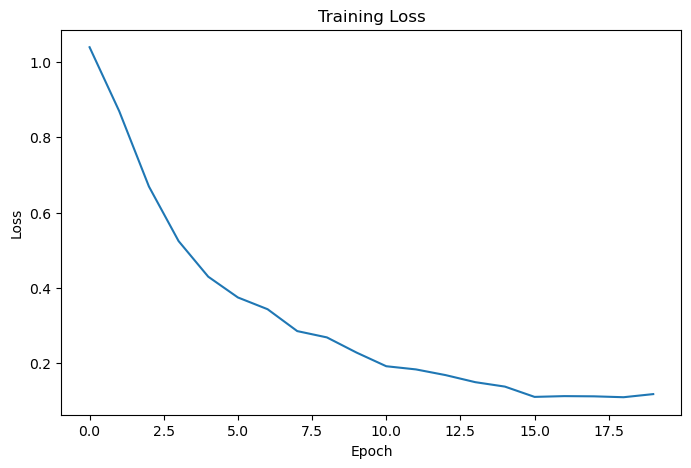

In [26]:

plt.figure(figsize=(8, 5))
plt.plot(history_loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


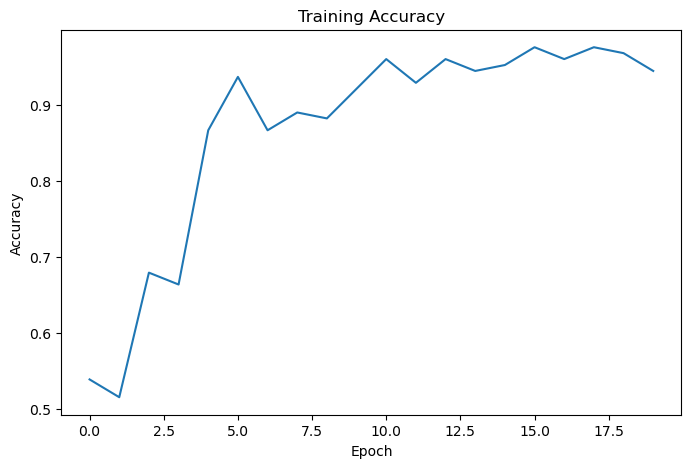

In [27]:

plt.figure(figsize=(8, 5))
plt.plot(history_acc)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


## 26) Save and load model weights

In [28]:

from pathlib import Path

Path("saved_models").mkdir(exist_ok=True)
save_path = "saved_models/iris_pytorch_model.pth"

torch.save(model.state_dict(), save_path)

loaded_model = IrisClassifier().to(device)
loaded_model.load_state_dict(torch.load(save_path, map_location=device))
loaded_model.eval()

print("Saved model to:", save_path)
print("Loaded model successfully.")


Saved model to: saved_models/iris_pytorch_model.pth
Loaded model successfully.


## 27) Custom Dataset example

In [31]:

class SimpleDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

custom_dataset = SimpleDataset(X_train, y_train)
custom_loader = DataLoader(custom_dataset, batch_size=8, shuffle=True)

for xb, yb in custom_loader:
    print("Custom dataset batch:", xb.shape, yb.shape)
    break


Custom dataset batch: torch.Size([8, 4]) torch.Size([8])


## 28) CNN example

In [32]:

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(),
            nn.Flatten()
        )
        self.classifier = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn = SmallCNN()
dummy_images = torch.randn(8, 1, 14, 14)
cnn_output = cnn(dummy_images)

print("CNN output shape:", cnn_output.shape)
print(cnn)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (8x512 and 800x10)

## 29) Inference helpers: eval mode and no_grad

In [33]:

dropout_model = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(8, 3)
)

x_sample = torch.randn(2, 4)

dropout_model.train()
train_out = dropout_model(x_sample)

dropout_model.eval()
with torch.no_grad():
    eval_out = dropout_model(x_sample)

print("Train mode output:\n", train_out)
print("\nEval mode output:\n", eval_out)


Train mode output:
 tensor([[ 0.3479, -0.5307, -0.0045],
        [ 1.5509, -0.9435, -0.8371]], grad_fn=<AddmmBackward0>)

Eval mode output:
 tensor([[ 0.1827, -0.3497,  0.1048],
        [ 1.0969, -0.9583, -0.4989]])


## 30) torch.compile

In [34]:

# torch.compile is available in newer PyTorch 2.x versions.
# This cell checks safely before trying it.

simple_model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 3)
)

if hasattr(torch, "compile"):
    try:
        compiled_model = torch.compile(simple_model)
        out = compiled_model(torch.randn(4, 4))
        print("torch.compile worked.")
        print("Output shape:", out.shape)
    except Exception as e:
        print("torch.compile exists, but this environment could not run it.")
        print("Reason:", e)
else:
    print("torch.compile is not available in this PyTorch version.")


Error while loading conda entry point: anaconda-auth (cannot import name 'RootModel' from 'pydantic' (/opt/homebrew/anaconda3/lib/python3.12/site-packages/pydantic/__init__.cpython-312-darwin.so))
Error while loading conda entry point: conda-libmamba-solver (dlopen(/opt/homebrew/anaconda3/lib/python3.12/site-packages/libmambapy/bindings.cpython-312-darwin.so, 0x0002): Library not loaded: @rpath/libarchive.20.dylib
  Referenced from: <496442DC-0EDE-3705-A2B5-401A4FC0D733> /opt/homebrew/anaconda3/lib/libmamba.2.0.0.dylib
  Reason: tried: '/opt/homebrew/anaconda3/lib/libarchive.20.dylib' (no such file), '/opt/homebrew/anaconda3/lib/python3.12/site-packages/libmambapy/../../../libarchive.20.dylib' (no such file), '/opt/homebrew/anaconda3/lib/python3.12/site-packages/libmambapy/../../../libarchive.20.dylib' (no such file), '/opt/homebrew/anaconda3/bin/../lib/libarchive.20.dylib' (no such file), '/opt/homebrew/anaconda3/bin/../lib/libarchive.20.dylib' (no such file), '/usr/local/lib/libarchi

torch.compile worked.
Output shape: torch.Size([4, 3])


## 31) Useful modules in PyTorch

In [35]:

common_modules = {
    "Tensor ops": ["torch.tensor", "zeros", "ones", "rand", "randn", "arange", "reshape", "cat", "stack"],
    "Math": ["add", "sub", "mul", "div", "matmul", "sum", "mean", "max", "argmax", "softmax"],
    "Autograd": ["requires_grad", "backward", "torch.no_grad"],
    "Neural networks": ["nn.Module", "nn.Sequential", "nn.Linear", "nn.Conv2d", "nn.ReLU", "nn.Dropout"],
    "Losses": ["nn.CrossEntropyLoss", "nn.MSELoss", "nn.BCEWithLogitsLoss"],
    "Optimizers": ["torch.optim.SGD", "torch.optim.Adam", "torch.optim.RMSprop"],
    "Data": ["Dataset", "TensorDataset", "DataLoader"],
    "Utilities": ["torch.save", "torch.load", "model.state_dict", "model.eval", "model.train"],
}

for category, items in common_modules.items():
    print(f"\n{category}:")
    print(", ".join(items))



Tensor ops:
torch.tensor, zeros, ones, rand, randn, arange, reshape, cat, stack

Math:
add, sub, mul, div, matmul, sum, mean, max, argmax, softmax

Autograd:
requires_grad, backward, torch.no_grad

Neural networks:
nn.Module, nn.Sequential, nn.Linear, nn.Conv2d, nn.ReLU, nn.Dropout

Losses:
nn.CrossEntropyLoss, nn.MSELoss, nn.BCEWithLogitsLoss

Optimizers:
torch.optim.SGD, torch.optim.Adam, torch.optim.RMSprop

Data:
Dataset, TensorDataset, DataLoader

Utilities:
torch.save, torch.load, model.state_dict, model.eval, model.train


## 32) Inspect library names

In [36]:

public_torch_names = [name for name in dir(torch) if not name.startswith("_")]
print("Some public names in torch:")
print(public_torch_names[:200])
print("\nTotal shown:", len(public_torch_names))


Some public names in torch:
['AVG', 'AggregationType', 'AliasDb', 'AnyType', 'Argument', 'ArgumentSpec', 'AwaitType', 'BFloat16Storage', 'BFloat16Tensor', 'BenchmarkConfig', 'BenchmarkExecutionStats', 'Block', 'BoolStorage', 'BoolTensor', 'BoolType', 'BufferDict', 'ByteStorage', 'ByteTensor', 'CallStack', 'Capsule', 'CharStorage', 'CharTensor', 'ClassType', 'Code', 'CompilationUnit', 'CompleteArgumentSpec', 'ComplexDoubleStorage', 'ComplexFloatStorage', 'ComplexType', 'ConcreteModuleType', 'ConcreteModuleTypeBuilder', 'DeepCopyMemoTable', 'DeserializationStorageContext', 'DeviceObjType', 'DictType', 'DisableTorchFunction', 'DisableTorchFunctionSubclass', 'DispatchKey', 'DispatchKeySet', 'DoubleStorage', 'DoubleTensor', 'EnumType', 'ErrorReport', 'Event', 'ExcludeDispatchKeyGuard', 'ExecutionPlan', 'FatalError', 'FileCheck', 'FloatStorage', 'FloatTensor', 'FloatType', 'FunctionSchema', 'Future', 'FutureType', 'Generator', 'GradScaler', 'Gradient', 'Graph', 'GraphExecutorState', 'HalfSto

In [37]:

public_nn_names = [name for name in dir(nn) if not name.startswith("_")]
print("Some public names in torch.nn:")
print(public_nn_names[:150])
print("\nTotal shown:", len(public_nn_names))


Some public names in torch.nn:
['AdaptiveAvgPool1d', 'AdaptiveAvgPool2d', 'AdaptiveAvgPool3d', 'AdaptiveLogSoftmaxWithLoss', 'AdaptiveMaxPool1d', 'AdaptiveMaxPool2d', 'AdaptiveMaxPool3d', 'AlphaDropout', 'AvgPool1d', 'AvgPool2d', 'AvgPool3d', 'BCELoss', 'BCEWithLogitsLoss', 'BatchNorm1d', 'BatchNorm2d', 'BatchNorm3d', 'Bilinear', 'Buffer', 'CELU', 'CTCLoss', 'ChannelShuffle', 'CircularPad1d', 'CircularPad2d', 'CircularPad3d', 'ConstantPad1d', 'ConstantPad2d', 'ConstantPad3d', 'Container', 'Conv1d', 'Conv2d', 'Conv3d', 'ConvTranspose1d', 'ConvTranspose2d', 'ConvTranspose3d', 'CosineEmbeddingLoss', 'CosineSimilarity', 'CrossEntropyLoss', 'CrossMapLRN2d', 'DataParallel', 'Dropout', 'Dropout1d', 'Dropout2d', 'Dropout3d', 'ELU', 'Embedding', 'EmbeddingBag', 'FeatureAlphaDropout', 'Flatten', 'Fold', 'FractionalMaxPool2d', 'FractionalMaxPool3d', 'GELU', 'GLU', 'GRU', 'GRUCell', 'GaussianNLLLoss', 'GroupNorm', 'Hardshrink', 'Hardsigmoid', 'Hardswish', 'Hardtanh', 'HingeEmbeddingLoss', 'HuberLo

## 33) Later topics you will likely use

In [38]:

later_topics = [
    "torchvision datasets and pretrained models",
    "learning rate schedulers",
    "mixed precision with torch.amp",
    "distributed training",
    "TensorBoard logging",
    "transfer learning",
    "checkpointing",
]

for topic in later_topics:
    print("-", topic)


- torchvision datasets and pretrained models
- learning rate schedulers
- mixed precision with torch.amp
- distributed training
- TensorBoard logging
- transfer learning
- checkpointing



## 34) Practice exercises

1. Create a tensor of shape `(3, 4)` filled with ones.
2. Reshape a 1D tensor of length 12 into a `(4, 3)` matrix.
3. Compute the gradient of `y = x^3` at `x = 2`.
4. Build a small `nn.Sequential` model with 2 hidden layers.
5. Train a classifier on the Iris dataset.
6. Add dropout to the model and compare train vs eval mode.
7. Save the model weights and reload them.
8. Create a CNN and verify its output shape on dummy images.



## 35) Summary

You now have a notebook that introduces the main PyTorch workflow:

- tensors and tensor operations
- autograd and gradients
- data loading with `Dataset` and `DataLoader`
- building models with `nn.Module`
- losses, optimizers, training, and evaluation
- saving and loading weights
- inference with `eval()` and `torch.no_grad()`
- a CNN example
- `torch.compile`

This is the core path used in many PyTorch projects.
